# Willmore example

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

Running Simulation...: 100%|█████████████| 100/100 [00:44<00:00,  2.26it/s]


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

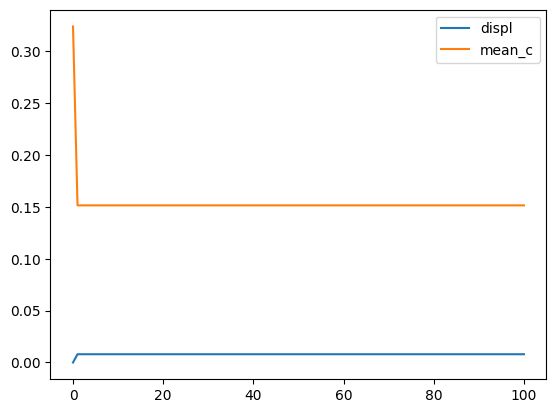

In [ ]:
# %%

from cosmos.solvers.willmore import StabWillmoreSolver
from cosmos.solvers.base_problem import MovingProblem
from cosmos.solvers.mesh_moving import HarmonicMMSolver
from cosmos.utils.generate_surface_meshes import generate_half_sphere
from ngsolve import *
import numpy as np
from ngsolve.webgui import Draw
import matplotlib.pyplot as plt


mesh, _ = generate_half_sphere(R=1)
Draw(mesh)

n_ex = CF((x,y,z))/Norm(CF((x,y,z)))

'''
Definition of the time parameters
'''
T = 1
dt = Parameter(0.01)
t =Parameter(0)

'''
Definition of the simulation
'''
simulation = MovingProblem(mesh=mesh, dt=dt, t=t, T=T)

displ_solver = StabWillmoreSolver(sp_curv = -2, clamped_bc = 'bottom')
simulation.attach_displ_solver(displ_solver)

def velocity():
    V = displ_solver.get_solution()[0]/simulation.dt.Get()
    return V
# harmonic_mm_sol = HarmonicMMSolver(velocity=velocity)
# simulation.attach_mm_solver(harmonic_mm_sol)


simulation.run()

displ_solver.draw_solution()


err = displ_solver.compute_error([CF((0,0,0)), -2*n_ex], 'L2')
plt.plot(err[0], label = 'displ')
plt.plot(err[1], label = 'mean_c')
plt.legend()
plt.show()


In [ ]:
# %%

from cosmos.solvers.willmore import StabWillmoreSolver
from cosmos.solvers.simulation import MovingProblem
from cosmos.solvers.mesh_moving import HarmonicMMSolver
from cosmos.utils.generate_surface_meshes import generate_half_torus
from ngsolve import *
import numpy as np
from ngsolve.webgui import Draw
import matplotlib.pyplot as plt

r = 1
R = sqrt(2)

mesh, _ = generate_half_torus(R=R, r=r, maxh = 0.2)
Draw(mesh)

displ_ex = CF((0, 0, 0))

n = CF((x,y,z))/r-R*CF((x,0,z))/r/sqrt(x**2+z**2)
cosv = (sqrt(x**2+z**2)-R)/r
H = 2*(R+2*r*cosv)/(2*r*(R+r*cosv))
mc_exact = -n*H

'''
Definition of the time parameters
'''
T = 1
dt = Parameter(0.1)
t =Parameter(0)

'''
Definition of the simulation
'''
simulation = MovingProblem(mesh=mesh, dt=dt, t=t, T=T)

displ_solver = StabWillmoreSolver(clamped_bc = 'bottom')
simulation.attach_displ_solver(displ_solver)

def velocity():
    V = displ_solver.get_solution()[0]/simulation.dt.Get()
    return V
# harmonic_mm_sol = HarmonicMMSolver(velocity=velocity)
# simulation.attach_mm_solver(harmonic_mm_sol)


simulation.run()

displ_solver.draw_solution()


err = displ_solver.compute_error([displ_ex, mc_exact], 'L2')
plt.plot(err[0], label = 'displ')
plt.plot(err[1], label = 'mean_c')
plt.legend()
plt.show()


ModuleNotFoundError: No module named 'cosmos.solvers.base_problem'